### Analsis y procesamiento de señales
## Trabajo Practico N^1
# Bernardita Aragon

A lo largo de este trabajo se sintetizan distintas señales utilizando siempre N=1000 muestras. Cada señal se representara en el dominio del tiempo, se calculara el modulo de su Transformada de Fourier atraves de la FFT, y se representaran ambas graficamente.
Se trabajará con una frecuencia de muestreo adecuada para representar una señal de 2 kHz con al menos 10 muestras por período. 
Además, se generarán señales senoidales, ruido con distintas distribuciones y un pulso rectangular.

In [8]:
#importacion de modulos
import numpy as np
import matplotlib.pyplot as plt 
import scipy.signal as sig

## Inciso 1 - Señal senoidal de 2 kHz
Sintetizar una señal senoidal de 2 kHz con al menos 10 muestras por período.

El periodo de la señal es: T=1/ff Siendo ff la frecuencia dada en la consigna ff= 2 kHz = 2000 Hz. T=1/2000Hz= 0.0005 s. Para obtener 10 muestras por periodo se necesita: Ts = T/10 = 0.00005 s Por lo tanto, la frecuencia de muestreo elegida es: fs = 1/Ts = 20000 Hz

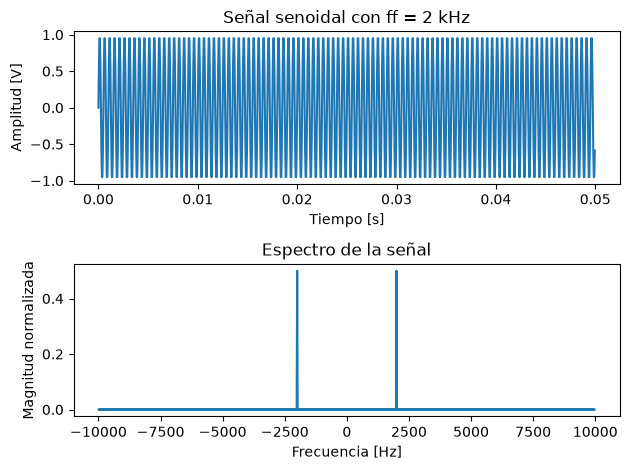

In [9]:
N=1000 
fs= 20000 
ts= 1/fs 
vmax = 1  
dc = 0     
ph = 0    
ff = 2000  

#de muestras a tiempo
tt = np.arange(0, N) * ts 
#ecuacion de la senal
xx = dc + vmax*np.sin(2*np.pi*ff*tt + ph)
#fft para pasar de muestras en tiempo a muestras en frecuencia
XX = np.fft.fft(xx)
#calculo su modulo
XX_modulo = np.abs(XX)/N
#vector de frecuencias
ff_vec = np.fft.fftfreq(N,ts ) 

#graficos
plt.figure()

plt.subplot(2,1,1)
plt.plot(tt, xx)
plt.title("Señal senoidal con ff = 2 kHz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")

plt.subplot(2,1,2)
plt.plot(ff_vec, XX_modulo)
plt.title("Espectro de la señal")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud normalizada")

plt.tight_layout() 
plt.show()

En el primer grafico, que representa el dominio del tiempo, se observa la señal senoidal de 2 kHz generada con 10 muestras por período.
En el segundo grafico, en dominio de la frecuencia, aparecen dos picos simétricos en aproximadamente +2 kHz y -2 kHz, correspondientes a la frecuencia de la señal. La simetría se debe a que la señal en el tiempo es real.

## Inciso 2 - Señal senoidal de 2 kHz, potencia media 2 W y fase π/2
Se utiliza la misma señal senoidal del inciso anterior, manteniendo la frecuencia de 2 kHz, pero modificando su amplitud para obtener una potencia media de 2 W y agregando un desfase de π/2.

Para una señal senoidal la potencia media esta definida como:
P= vmax^2/ 2.
En nuestro caso P=2, asi que despajando, vmax=2.

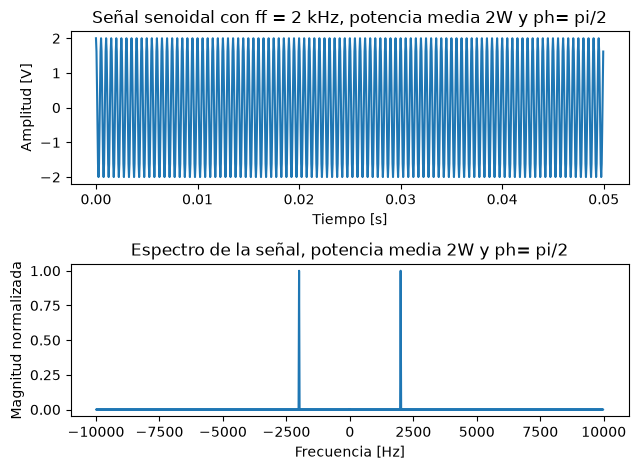

In [10]:
vmax = 2
ph = np.pi/2
#calculo nuevamente la senal con los nuevos valores
xx = dc + vmax*np.sin(2*np.pi*ff*tt + ph)
XX = np.fft.fft(xx)
XX_modulo = np.abs(XX)/N

#graficos

plt.figure()
plt.subplot(2,1,1)
plt.plot(tt, xx)
plt.title("Señal senoidal con ff = 2 kHz, potencia media 2W y ph= pi/2")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")

plt.subplot(2,1,2)
plt.plot(ff_vec, XX_modulo)
plt.title("Espectro de la señal, potencia media 2W y ph= pi/2")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud normalizada")

plt.tight_layout()
plt.show()

En el dominio del tiempo, se observa claramente como la señal conserva la frecuencia de 2 kHz pero presenta una amplitud mayor y un corrimiento de fase respecto de la señal anterior, que son justamente los datos que cambiamos.

En el dominio de la frecuencia, los picos continúan ubicados en ±2 kHz, por lo que no aparecen nuevas componentes frecuenciales. Su magnitud normalizada aumenta aproximadamente de 0,5 a 1 debido al aumento de amplitud, mientras que el desfase no modifica el módulo del espectro.

## Inciso 3 - Ruido normalmente distribuido
Se genera una secuencia aleatoria de N = 1000 muestras con distribución normal, valor medio 0 V y varianza 0.1 W.

Para generar valores aleatorios para crear el ruido normalmente distribuido, utilice la funcion `np.random.normal`, esta necesita utilizar como parametro el desvio estandar.Este dato lo podemos calcular a traves d ela varianza, que es el dato brindado por el ejercicio:
varianza= (desvio estandar)^2

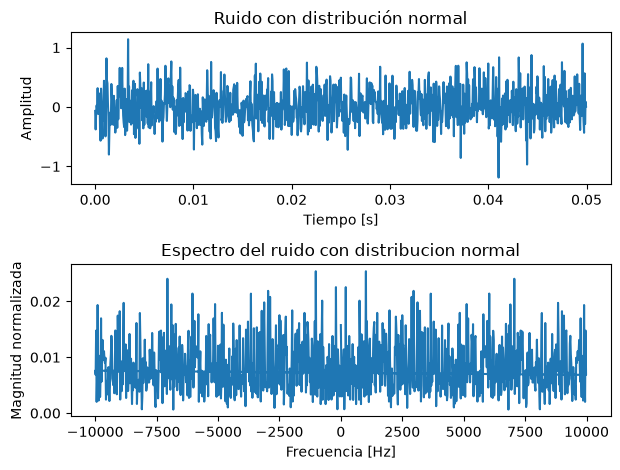

In [11]:
dc= 0 
varianza=0.1
sigma= np.sqrt(varianza) #desvio estandar

ruido_normal = np.random.normal(dc, sigma, N)
RN = np.fft.fft(ruido_normal)
RN_modulo = np.abs(RN)/N

#graficos

plt.figure()
plt.subplot(2,1,1)
plt.plot(tt, ruido_normal)
plt.title("Ruido con distribución normal")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.subplot(2,1,2)
plt.plot(ff_vec, RN_modulo)
plt.title("Espectro del ruido con distribucion normal")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud normalizada")

plt.tight_layout()
plt.show()

En el dominio del tiempo, el ruido presenta variaciones aleatorias alrededor de 0 V, sin periodicidad definida. Mientras que, en el dominio de la frecuencia, las componentes se encuentran distribuidas a lo largo de todo el espectro, a diferencia de las señales senoidales anteriores, donde la energía se concentraba en ±2 kHz.

## Inciso 4 - Ruido uniformemente distribuido

Se genera una secuencia aleatoria de N = 1000 muestras con distribución uniforme, valor medio 0 V y varianza 0.1 W.


Para generar valores aleatorios con distribución uniforme voy a utilizar la función `np.random.uniform`. Esta función necesita conocer el límite inferior `a`, el límite superior `b` y la cantidad de muestras `N`. 

Como la consigna me da la varianza y el valor medio, puedo obtener el valor de rango ya que: varianza= (rango)^2/12

Entonces apartir del rango puedo conocer el limite inferior y superior:
a = -rango/2 , 
b = rango/2

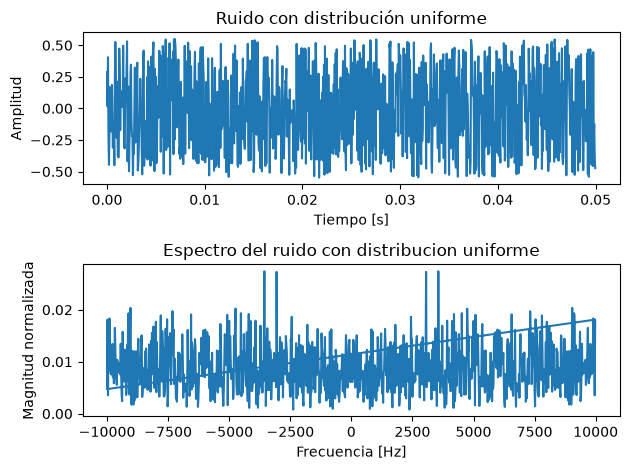

In [12]:
rango = np.sqrt(12*varianza)
a = -rango/2
b = rango/2

ruido_uniforme = np.random.uniform(a, b, N)
RU = np.fft.fft(ruido_uniforme)
RU_modulo = np.abs(RU)/N

#graficos
plt.figure()
plt.subplot(2,1,1)
plt.plot(tt, ruido_uniforme)
plt.title("Ruido con distribución uniforme")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

plt.subplot(2,1,2)
plt.plot(ff_vec, RU_modulo)
plt.title("Espectro del ruido con distribucion uniforme")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud normalizada")

plt.tight_layout()
plt.show()

En el gráfico temporal se ve que el ruido toma valores aleatorios, pero siempre dentro de un rango aproximado entre -0.55 y +0.55. 

En el espectro no aparece una frecuencia principal, sino que las componentes están repartidas en todo el rango. 

A diferencia del ruido normal, este ruido queda limitado entre dos valores definidos.

## Inciso 5 - Pulso rectangular
Debemos generar un pulso rectangular de la misma frecuencia que los incisos anteriores, con 1W de potencia y ciclo de actividad del 50%.

Para generar el pulso rectangular voy a utilizar la función `sig.square` de `scipy.signal`. Esta función necesita como entrada la frecuencia de la señal y el ciclo de actividad. Como la consigna pide la misma frecuencia que antes, utilizo `ff = 2000 Hz`.

El ciclo de actividad pedido es del 50%, por lo tanto: duty = 0.5

La función `square` genera una señal que toma valores entre +1 y -1. Como ambos valores al cuadrado dan 1, la potencia media de la señal es 1 W.

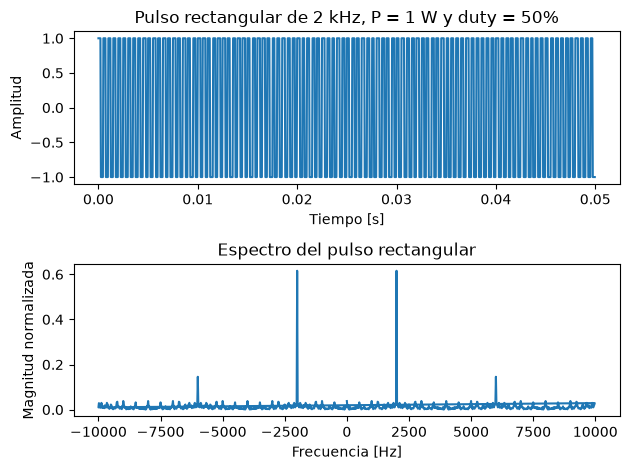

In [13]:
duty=0.5

pulso= sig.square(2*np.pi*ff*tt, duty)
PR = np.fft.fft(pulso)
PR_modulo = np.abs(PR)/N

#graficos

plt.figure()
plt.subplot(2,1,1)
plt.plot(tt, pulso)
plt.title("Pulso rectangular de 2 kHz, P = 1 W y duty = 50%")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

plt.subplot(2,1,2)
plt.plot(ff_vec, PR_modulo)
plt.title("Espectro del pulso rectangular")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud normalizada")

plt.tight_layout()
plt.show()


En el dominio del tiempo se observa que la señal cambia periódicamente entre +1 y -1, permaneciendo aproximadamente la mitad del período en cada nivel, como corresponde a un ciclo de actividad del 50 %.
En el espectro aparece la componente principal en ±2 kHz y también otras componentes en frecuencias mayores. A diferencia de una senoide, el pulso rectangular contiene armónicos debido a los cambios bruscos entre sus dos niveles.

## Bonus - Señal sawtooth

Como bonus voy a generar una señal adicional disponible en `scipy.signal`. En este caso utilizo la función `sig.sawtooth`, que genera una señal tipo "diente de sierra".

Para mantener la misma frecuencia utilizada en los incisos anteriores, voy a utilizar `ff = 2000 Hz`.

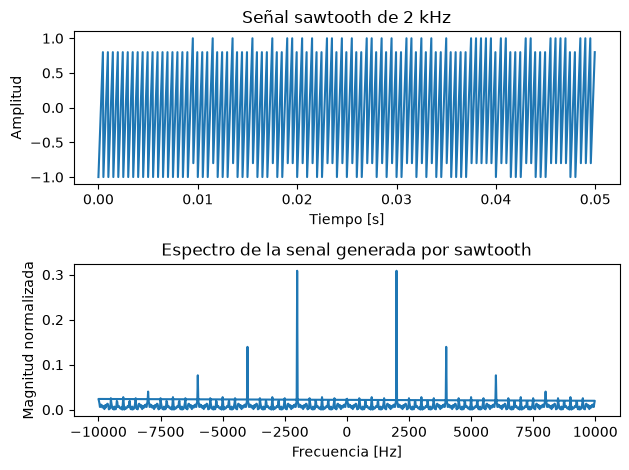

In [14]:
funcion_sawtooth = sig.sawtooth(2*np.pi*ff*tt)
S = np.fft.fft(funcion_sawtooth)
S_modulo = np.abs(S)/N

#graficos

plt.figure()
plt.subplot(2,1,1)
plt.plot(tt, funcion_sawtooth)
plt.title("Señal sawtooth de 2 kHz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

plt.subplot(2,1,2)
plt.plot(ff_vec, S_modulo)
plt.title("Espectro de la senal generada por sawtooth")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud normalizada")

plt.tight_layout()
plt.show()

En el dominio del tiempo se observa una señal periódica que varía entre aproximadamente -1 y 1. 

En el espectro aparece la componente principal en ±2 kHz y también varios armónicos en múltiplos de esa frecuencia, cuya magnitud va disminuyendo. 

A diferencia de la senoide, la señal sawtooth necesita varias componentes de frecuencia para formar su característica forma de diente de sierra.

## Conclusion
En este trabajo práctico aprendimos a sintetizar distintos tipos de señales y a observar cómo cambian al modificar sus parámetros, pudiendo relacionar lo que vemos en el dominio del tiempo con su representación en frecuencia. A partir de la FFT pudimos analizar el módulo de cada señal y ver, por ejemplo, cómo la potencia modifica la amplitud y la magnitud del espectro, y cómo señales como el pulso rectangular o la sawtooth presentan más componentes frecuenciales que una senoide. También pudimos comparar distintos tipos de ruido y reconocer que el ruido uniforme queda acotado entre valores definidos.